In [1]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.2 MB/s eta 0:00:00


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import Ridge
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.model_selection import KFold
import optuna
size_text =24
plt.rcParams.update({
    #'font.family': 'serif',
    #'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

p = 10
q = 6

In [4]:
df = pd.read_csv("Case_2.csv")

X = df[['R', 'b']]
y = df['Fij']

df.shape

(40000, 3)

# Train - Test Set

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [6]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Convert data to tensors

In [7]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled.reshape(-1, 1), dtype=torch.float32)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl  = DataLoader(test_ds , batch_size=256, shuffle=False)

# Search for the best model

In [ ]:
import torch.optim as optim

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

def create_model(input_dim, hidden_size, num_layers, activation_name):
    layers = []
    layers.append(nn.Linear(input_dim, hidden_size))
    activation_fn = getattr(nn, activation_name)()
    layers.append(activation_fn)

    for _ in range(num_layers - 1):
        layers.append(nn.Linear(hidden_size, hidden_size))
        layers.append(getattr(nn, activation_name)())

    layers.append(nn.Linear(hidden_size, 1))
    return nn.Sequential(*layers)

def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 4)
    activation_name = trial.suggest_categorical("activation", ["ReLU", "Tanh", "LeakyReLU"])
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)

    model = create_model(input_dim=2, hidden_size=hidden_size, num_layers=num_layers, activation_name=activation_name)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(100):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

    # Validación
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        loss = mean_squared_error(y_test_tensor.numpy(), y_pred.numpy())
    return loss  # Optuna minimiza

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Mejores hiperparámetros encontrados:")
print(study.best_params)

[I 2026-04-16 02:31:28,501] A new study created in memory with name: no-name-cd88a607-ee36-4c5b-89c9-ac85779b3079
/tmp/ipykernel_13274/3780010144.py:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-5, 1e-2)
[W 2026-04-16 02:31:41,510] Trial 0 failed with parameters: {'hidden_size': 34, 'num_layers': 1, 'activation': 'LeakyReLU', 'lr': 0.006643205509047808} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_13274/3780010144.py", line 27, in objective
    optimizer = optim.Adam(model.parameters(), lr=lr)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/

KeyboardInterrupt: 

{'hidden_size': 84, 'num_layers': 3, 'activation': 'LeakyReLU', 'lr': 0.0004596992922680162}

# Build the model

In [8]:
class BestMLP(nn.Module):
    def __init__(self):
        super(BestMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 84),
            nn.LeakyReLU(),
            nn.Linear(84, 84),
            nn.LeakyReLU(),
            nn.Linear(84, 84),
            nn.LeakyReLU(),
            nn.Linear(84, 1)
        )

    def forward(self, x):
        return self.net(x)

# Model training

In [9]:
model_best = BestMLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_best.parameters(), lr=0.0004597)

epochs = 500
train_losses = []
val_losses = []

for epoch in range(epochs):
    model_best.train()
    optimizer.zero_grad()
    outputs = model_best(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    model_best.eval()
    with torch.no_grad():
        val_loss = criterion(model_best(X_test_tensor), y_test_tensor)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.6f}, Test Loss: {val_loss.item():.6f}")

Epoch 100/500, Train Loss: 0.030291, Test Loss: 0.029135
Epoch 200/500, Train Loss: 0.012115, Test Loss: 0.011640
Epoch 300/500, Train Loss: 0.007233, Test Loss: 0.006850
Epoch 400/500, Train Loss: 0.005066, Test Loss: 0.004706
Epoch 500/500, Train Loss: 0.003824, Test Loss: 0.003467


# Measure execution time

In [ ]:
import time

t0 = time.perf_counter()

model_best = BestMLP()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_best.parameters(), lr=0.0004597)

epochs = 500
for epoch in range(epochs):
    model_best.train()
    optimizer.zero_grad()
    outputs = model_best(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        model_best.eval()
        with torch.no_grad():
            val_loss = criterion(model_best(X_test_tensor), y_test_tensor)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.6f}, Test Loss: {val_loss.item():.6f}")

t1 = time.perf_counter()
T_train_bestmlp = t1 - t0

print(f"\nBestMLP training time: {T_train_bestmlp:.6f} s")

model_best.eval()
with torch.no_grad():
    t2 = time.perf_counter()
    y_pred_best_test = model_best(X_test_tensor)
    t3 = time.perf_counter()

T_pred_bestmlp = t3 - t2
N_pred_best = X_test_tensor.shape[0]
t_pred_bestmlp = T_pred_bestmlp / N_pred_best

print(f"Total BestMLP prediction time (test set): {T_pred_bestmlp:.6f} s for {N_pred_best} samples")
print(f"BestMLP prediction time per sample: {t_pred_bestmlp:.8f} s/sample")

Epoch 100/500, Train Loss: 0.028409, Test Loss: 0.027665
Epoch 200/500, Train Loss: 0.012474, Test Loss: 0.011999
Epoch 300/500, Train Loss: 0.006334, Test Loss: 0.005924
Epoch 400/500, Train Loss: 0.003943, Test Loss: 0.003535
Epoch 500/500, Train Loss: 0.002791, Test Loss: 0.002393

BestMLP training time: 57.949456 s
Total BestMLP prediction time (test set): 0.011132 s for 8000 samples
BestMLP prediction time per sample: 0.00000139 s/sample


# Inverse scaling of data

In [10]:
model_best.eval()
with torch.no_grad():
    y_train_pred_scaled = model_best(X_train_tensor).numpy()
    y_test_pred_scaled = model_best(X_test_tensor).numpy()


y_train_true = scaler_y.inverse_transform(y_train_tensor.numpy())
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)

y_test_true = scaler_y.inverse_transform(y_test_tensor.numpy())
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)


def print_metrics(y_true, y_pred, dataset="Train"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Error porcentual medio absoluto

    print(f"Métricas para {dataset}:")
    print(f"MSE   : {mse:.6e}")
    print(f"RMSE  : {rmse:.6e}")
    print(f"MAE   : {mae:.6e}")
    print(f"R²    : {r2:.6f}")
    print(f"MAPE  : {mape:.4f} %")

# Metrics of training

In [11]:
print_metrics(y_train_true, y_train_pred, dataset="Train")

Métricas para Train:
MSE   : 1.505806e-04
RMSE  : 1.227113e-02
MAE   : 4.945549e-03
R²    : 0.996187
MAPE  : 0.9238 %


# Metrics of testing

In [12]:
print_metrics(y_test_true, y_test_pred, dataset="Test")

Métricas para Test:
MSE   : 1.369168e-04
RMSE  : 1.170115e-02
MAE   : 4.953383e-03
R²    : 0.996575
MAPE  : 0.9367 %


# Error training

In [16]:
tolerance_1 = 0.05  # 5%
Percentage = np.mean(np.abs((y_train_true - y_train_pred) / y_train_true) < tolerance_1) * 100
print(f"Predicciones con menos de 5% de error: {Percentage:.2f}%")

Predicciones con menos de 5% de error: 97.07%


# Error testing

In [14]:
tolerance_1 = 0.05  # 5%
Percentage = np.mean(np.abs((y_test_true - y_test_pred) / y_test_true) < tolerance_1) * 100
print(f"Predicciones con menos de 5% de error: {Percentage:.2f}%")

Predicciones con menos de 5% de error: 97.00%


# Learning curves

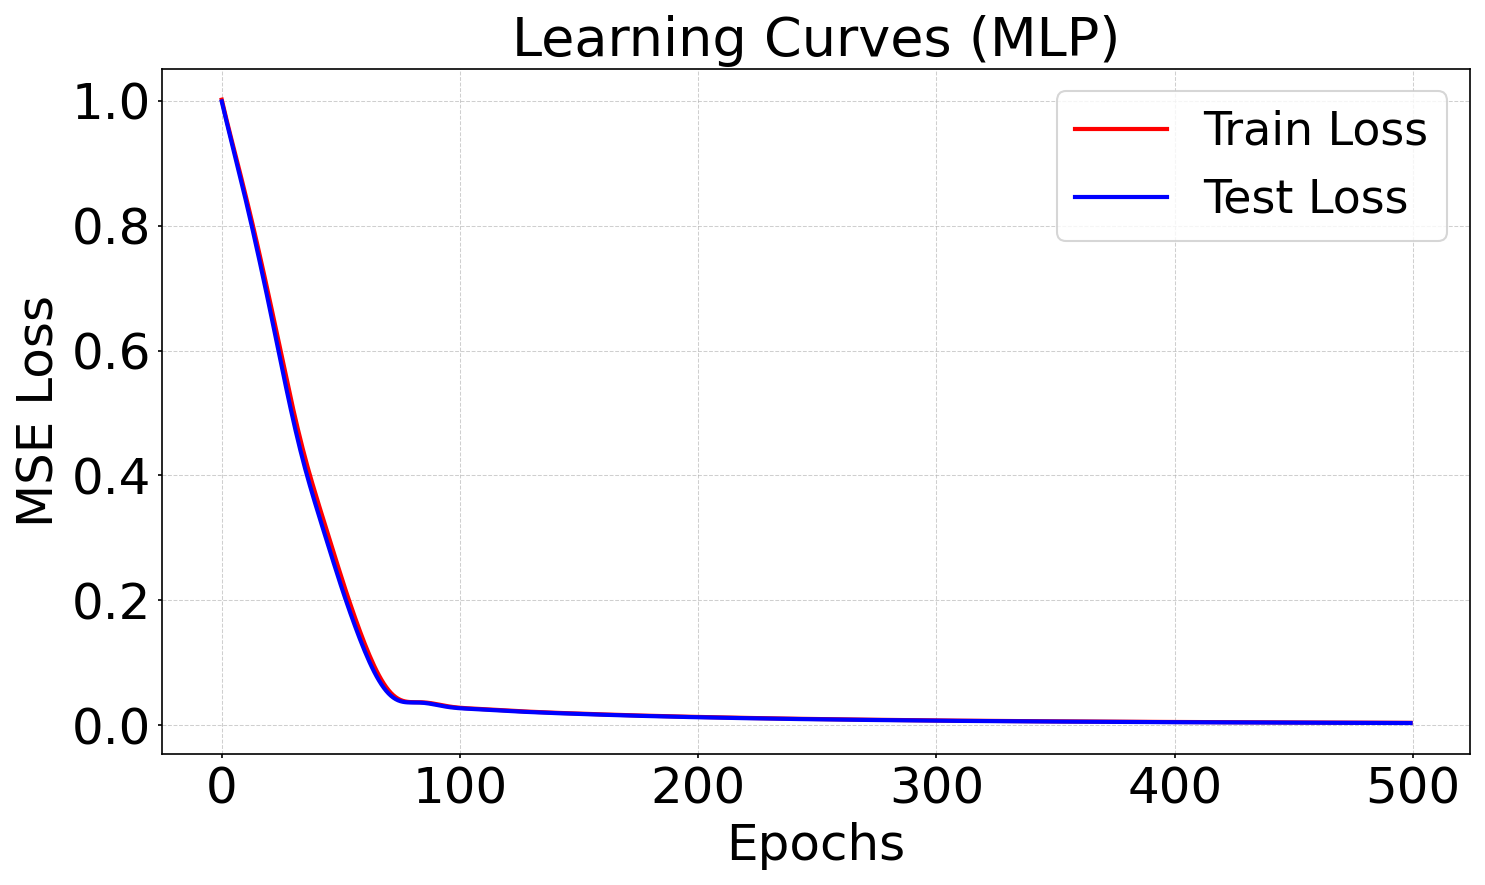

In [ ]:
size_text = 24


fig, ax = plt.subplots(figsize=(10, 6), dpi=150)


ax.plot(train_losses, label="Train Loss", color="red", linewidth=2)
ax.plot(val_losses, label="Test Loss", color="blue", linewidth=2)

ax.set_title("Learning Curves (MLP)", fontsize=size_text + 2)
ax.set_xlabel("Epochs", fontsize=size_text)
ax.set_ylabel("MSE Loss", fontsize=size_text)


ax.legend(fontsize=size_text - 2)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)


plt.tight_layout()
plt.savefig("learning_curve_mlp_loss.png", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_loss.pdf", dpi=400, bbox_inches='tight')
plt.savefig("learning_curve_mlp_loss.eps", dpi=400, bbox_inches='tight')

plt.show()

# Predicted vs Actual Values

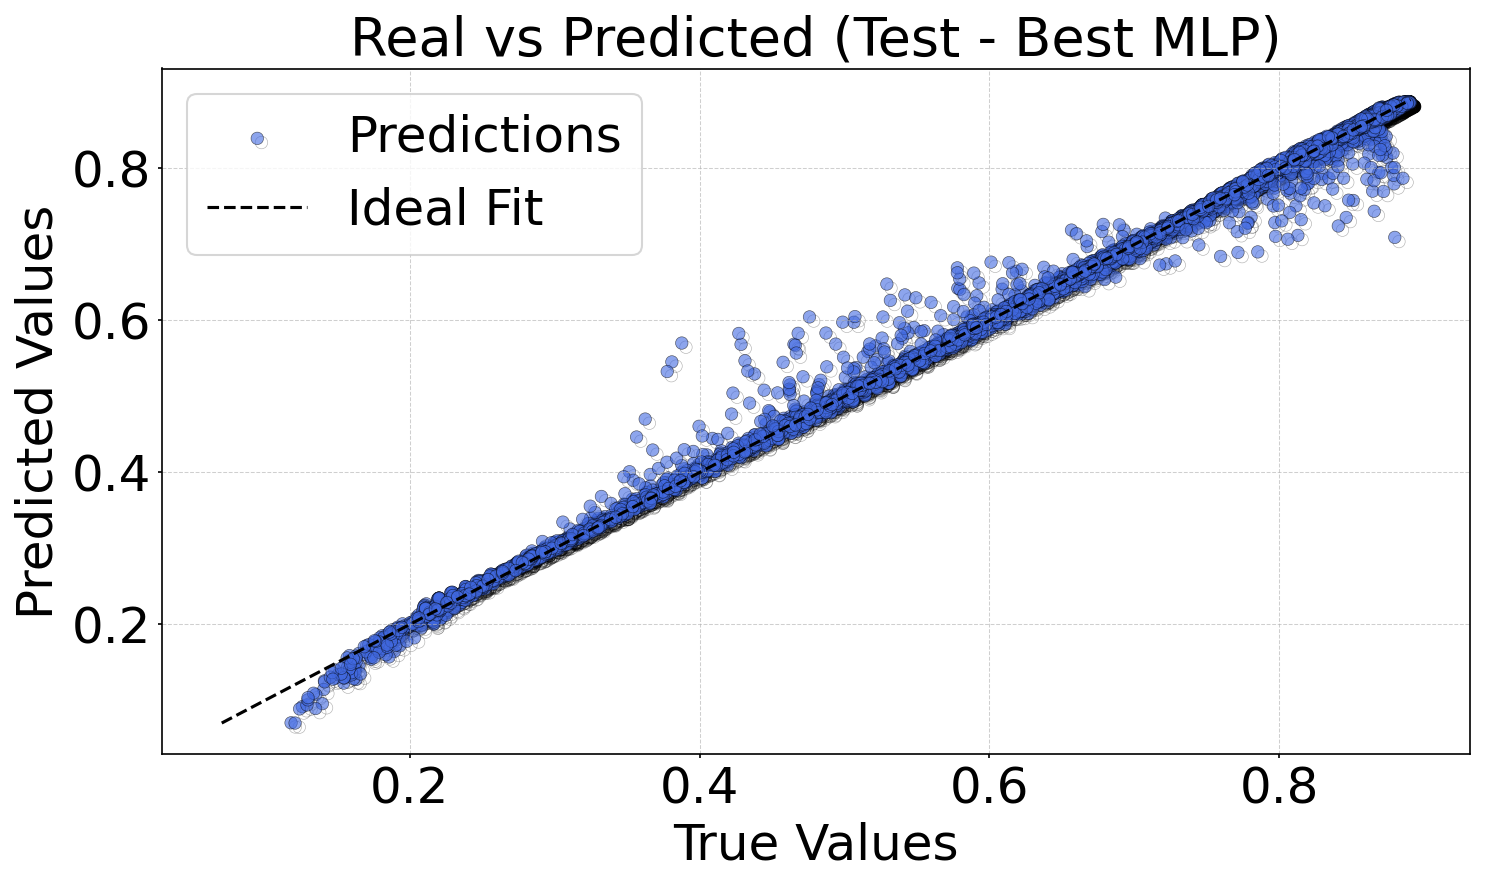

In [ ]:
import matplotlib.patheffects as pe


model_best.eval()
with torch.no_grad():
    y_pred_scaled_best = model_best(X_test_tensor)
    y_pred_best = scaler_y.inverse_transform(y_pred_scaled_best.numpy())
    y_test_real = scaler_y.inverse_transform(y_test_tensor.numpy())


fig, ax = plt.subplots(figsize=(p,q), dpi=150)


shadow = [pe.SimpleLineShadow(), pe.Normal()]


sc = ax.scatter(
    y_test_real, y_pred_best,
    alpha=0.6, color='royalblue',
    edgecolor='black', linewidth=0.3,
    label="Predictions"
)
sc.set_path_effects(shadow)


min_val = min(y_test_real.min(), y_pred_best.min())
max_val = max(y_test_real.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', label="Ideal Fit")


ax.set_title("Real vs Predicted (Test - Best MLP)", fontsize=size_text + 2)
ax.set_xlabel("True Values", fontsize=size_text)
ax.set_ylabel("Predicted Values", fontsize=size_text)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax.legend(fontsize=size_text)


plt.tight_layout()
plt.savefig("C2_real_vs_pred_best_mlp.pdf", dpi=400, bbox_inches='tight')
plt.show()